In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('data/chinook.db')

In [2]:
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query, conn)
print(tables)

             name
0           Album
1          Artist
2        Customer
3        Employee
4           Genre
5         Invoice
6     InvoiceLine
7       MediaType
8        Playlist
9   PlaylistTrack
10          Track


In [3]:
query = """
SELECT 
    Genre.Name AS genero,
    SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity) AS ingresos_totales
FROM InvoiceLine
JOIN Track ON InvoiceLine.TrackId = Track.TrackId
JOIN Genre ON Track.GenreId = Genre.GenreId
GROUP BY Genre.Name
ORDER BY ingresos_totales DESC;
"""

ingresos_por_genero = pd.read_sql_query(query, conn)
print(ingresos_por_genero)

                genero  ingresos_totales
0                 Rock            826.65
1                Latin            382.14
2                Metal            261.36
3   Alternative & Punk            241.56
4             TV Shows             93.53
5                 Jazz             79.20
6                Blues             60.39
7                Drama             57.71
8             R&B/Soul             40.59
9            Classical             40.59
10    Sci Fi & Fantasy             39.80
11              Reggae             29.70
12                 Pop             27.72
13          Soundtrack             19.80
14              Comedy             17.91
15         Hip Hop/Rap             16.83
16          Bossa Nova             14.85
17         Alternative             13.86
18               World             12.87
19     Science Fiction             11.94
20         Heavy Metal             11.88
21   Electronica/Dance             11.88
22      Easy Listening              9.90
23       Rock An

In [4]:
query2 = """
SELECT 
    Customer.FirstName || ' ' || Customer.LastName AS cliente,
    Customer.Country AS pais,
    SUM(Invoice.Total) AS gasto_total
FROM Customer
JOIN Invoice ON Customer.CustomerId = Invoice.CustomerId
GROUP BY Customer.CustomerId
ORDER BY gasto_total DESC
LIMIT 5;
"""

top_clientes = pd.read_sql_query(query2, conn)
print(top_clientes)

              cliente            pais  gasto_total
0         Helena Holý  Czech Republic        49.62
1  Richard Cunningham             USA        47.62
2          Luis Rojas           Chile        46.62
3     Ladislav Kovács         Hungary        45.62
4       Hugh O'Reilly         Ireland        45.62


In [5]:
query3 = """
SELECT 
    Customer.Country AS pais,
    COUNT(DISTINCT Customer.CustomerId) AS num_clientes,
    SUM(Invoice.Total) AS ingresos_totales,
    SUM(Invoice.Total) / COUNT(DISTINCT Customer.CustomerId) AS gasto_promedio
FROM Customer
JOIN Invoice ON Customer.CustomerId = Invoice.CustomerId
GROUP BY Customer.Country
ORDER BY ingresos_totales DESC
LIMIT 10;
"""

ventas_por_pais = pd.read_sql_query(query3, conn)
print(ventas_por_pais)

             pais  num_clientes  ingresos_totales  gasto_promedio
0             USA            13            523.06       40.235385
1          Canada             8            303.96       37.995000
2          France             5            195.10       39.020000
3          Brazil             5            190.10       38.020000
4         Germany             4            156.48       39.120000
5  United Kingdom             3            112.86       37.620000
6  Czech Republic             2             90.24       45.120000
7        Portugal             2             77.24       38.620000
8           India             2             75.26       37.630000
9           Chile             1             46.62       46.620000


<>:4: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:4: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\Usuario\AppData\Local\Temp\ipykernel_1952\1238404000.py:4: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  plt.xlabel('Ingresos (\$)')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_1952\1238404000.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ingresos_totales', y='genero', data=ingresos_por_genero.head(10), palette='mako')


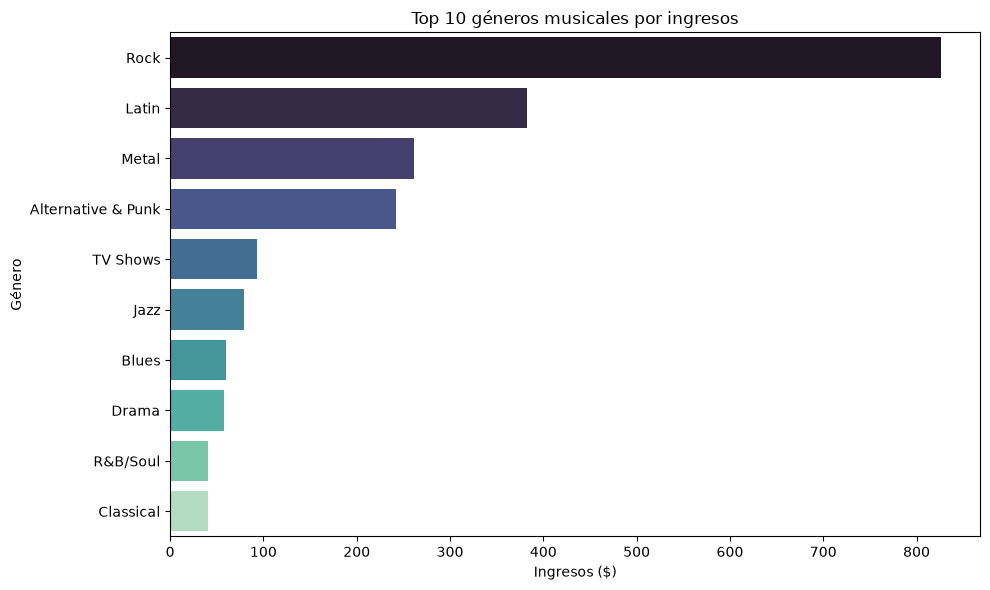

In [6]:
plt.figure(figsize=(10,6))
sns.barplot(x='ingresos_totales', y='genero', data=ingresos_por_genero.head(10), palette='mako')
plt.title('Top 10 géneros musicales por ingresos')
plt.xlabel('Ingresos (\$)')
plt.ylabel('Género')
plt.tight_layout()
plt.savefig('images/ingresos_por_genero.png', dpi=150)
plt.show()

<>:4: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:4: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\Usuario\AppData\Local\Temp\ipykernel_1952\3943838267.py:4: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  plt.xlabel('Ingresos (\$)')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_1952\3943838267.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ingresos_totales', y='pais', data=ventas_por_pais, palette='crest')


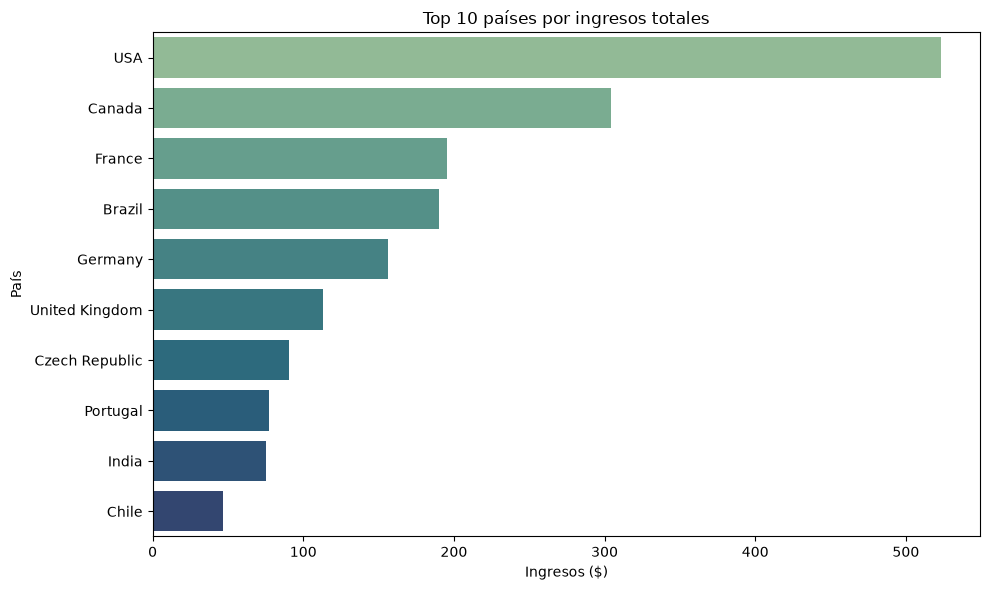

In [7]:
plt.figure(figsize=(10,6))
sns.barplot(x='ingresos_totales', y='pais', data=ventas_por_pais, palette='crest')
plt.title('Top 10 países por ingresos totales')
plt.xlabel('Ingresos (\$)')
plt.ylabel('País')
plt.tight_layout()
plt.savefig('images/ingresos_por_pais.png', dpi=150)
plt.show()

<>:5: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:5: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\Usuario\AppData\Local\Temp\ipykernel_1952\509979504.py:5: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  plt.xlabel('Gasto promedio (\$)')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_1952\509979504.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gasto_promedio', y='pais', data=ventas_ordenado, palette='flare')


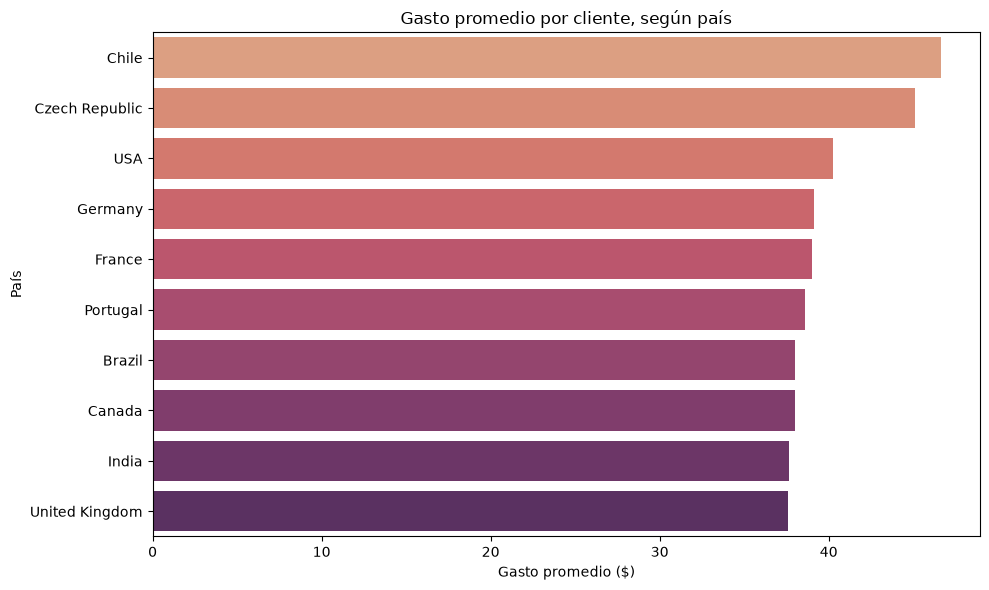

In [8]:
plt.figure(figsize=(10,6))
ventas_ordenado = ventas_por_pais.sort_values('gasto_promedio', ascending=False)
sns.barplot(x='gasto_promedio', y='pais', data=ventas_ordenado, palette='flare')
plt.title('Gasto promedio por cliente, según país')
plt.xlabel('Gasto promedio (\$)')
plt.ylabel('País')
plt.tight_layout()
plt.savefig('images/gasto_promedio_pais.png', dpi=150)
plt.show()

## Conclusiones

1. **Rock es, con diferencia, el género más rentable** (USD 826.65 en ingresos), 
   más del doble que el segundo puesto (Latin, USD 382.14). El catálogo y las 
   estrategias de marketing deberían priorizar este género.

2. **Estados Unidos es el mercado más importante en volumen**, con 13 clientes 
   y USD 523.06 en ingresos totales — muy por encima del resto de países.

3. **Sin embargo, el gasto promedio por cliente no sigue el mismo patrón**: 
   Chile y República Checa, con muy pocos clientes (1 y 2 respectivamente), 
   tienen el gasto promedio más alto (USD 46.62 y USD 45.12). Esto sugiere mercados 
   pequeños pero con clientes de alto valor, que podrían ser objetivo de 
   estrategias de fidelización o expansión.

4. **Recomendación de negocio**: mantener el foco comercial en Rock y en el 
   mercado de EE.UU. por volumen, pero explorar oportunidades de crecimiento 
   en mercados como Chile o República Checa, donde el gasto individual es 
   más alto de lo esperado.